<a href="https://www.kaggle.com/code/lalit7881/gold-price-trends-eda?scriptVersionId=309546176" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rifatalam3/gold-price-trends/finalgolddata.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/rifatalam3/gold-price-trends/finalgolddata.csv")

In [3]:
df.head()

,Date,Open,High,Low,Close,Volume
0,30-08-00,273.899994,273.899994,273.899994,273.899994,0
1,31-08-00,274.799988,278.299988,274.799988,278.299988,0
2,01-09-00,277.000000,277.000000,277.000000,277.000000,0
3,05-09-00,275.799988,275.799988,275.799988,275.799988,2
4,06-09-00,274.200012,274.200012,274.200012,274.200012,0


In [4]:
df.tail()

,Date,Open,High,Low,Close,Volume
6394,25-02-26,5166.000000,5206.399902,5166.000000,5206.399902,1772
6395,26-02-26,5177.200195,5199.200195,5143.899902,5176.500000,1520
6396,27-02-26,5186.700195,5280.000000,5176.700195,5230.500000,354
6397,02-03-26,5346.600098,5405.000000,5266.299805,5294.399902,354
6398,03-03-26,5335.700195,5394.200195,5334.899902,5377.299805,21189


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6399 entries, 0 to 6398
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6399 non-null   object 
 1   Open    6399 non-null   float64
 2   High    6399 non-null   float64
 3   Low     6399 non-null   float64
 4   Close   6399 non-null   float64
 5   Volume  6399 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 300.1+ KB


In [6]:
df.describe()

,Open,High,Low,Close,Volume
count,6399.000000,6399.000000,6399.000000,6399.000000,6399.000000
mean,1274.892437,1281.728724,1267.908032,1274.961009,4282.543522
std,782.868133,788.800733,777.090788,783.122438,24051.637361
min,255.000000,256.100006,255.000000,255.100006,0.000000
25%,651.000000,653.649994,649.149994,651.699982,23.000000
50%,1251.599976,1256.199951,1244.800049,1251.099976,117.000000
75%,1694.700012,1706.099976,1683.250000,1695.649964,450.500000
max,5415.700195,5586.200195,5334.899902,5377.299805,386334.000000


In [7]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Date       object
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

In [10]:
df.shape

(6399, 6)

In [11]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [12]:
df.nunique()

Date      6399
Open      5091
High      5075
Low       5039
Close     5144
Volume    1635
dtype: int64

## EDA

In [13]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.8 MB/s eta 0:00:00


In [14]:
import mplfinance as mpf

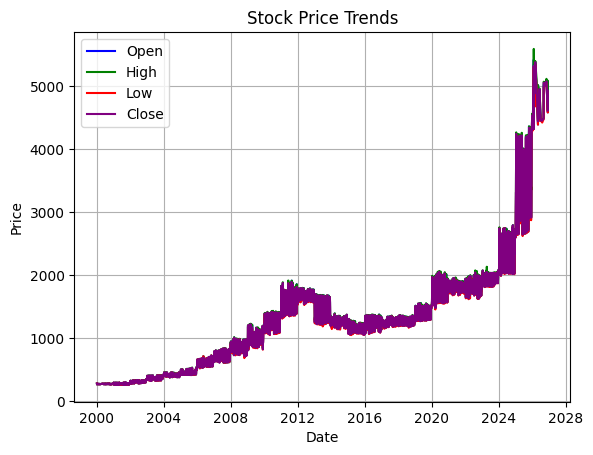

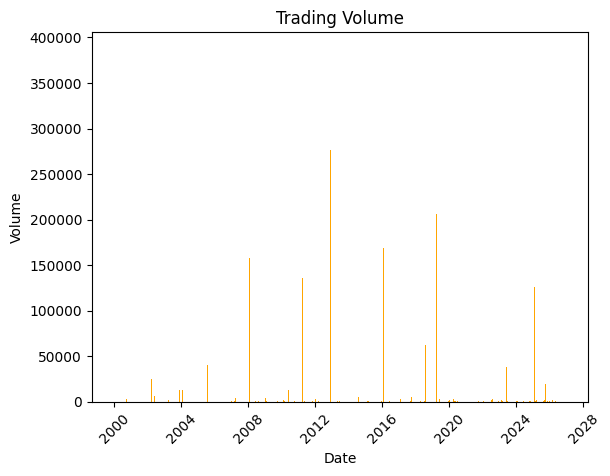

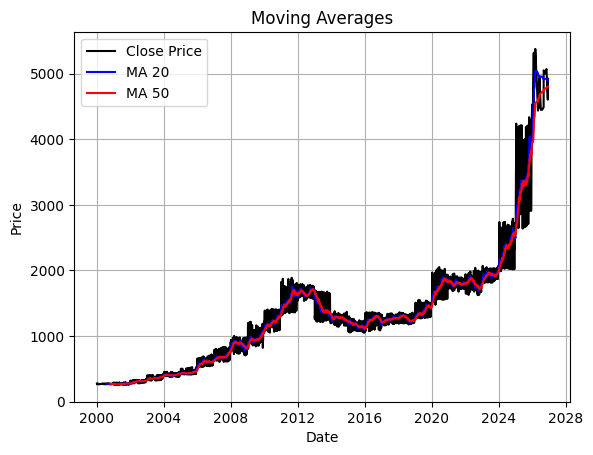

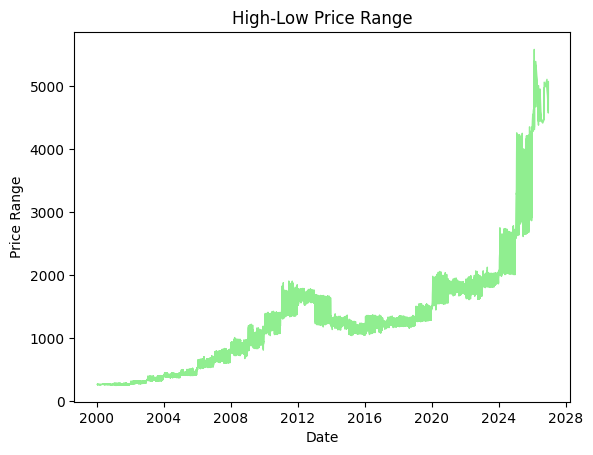

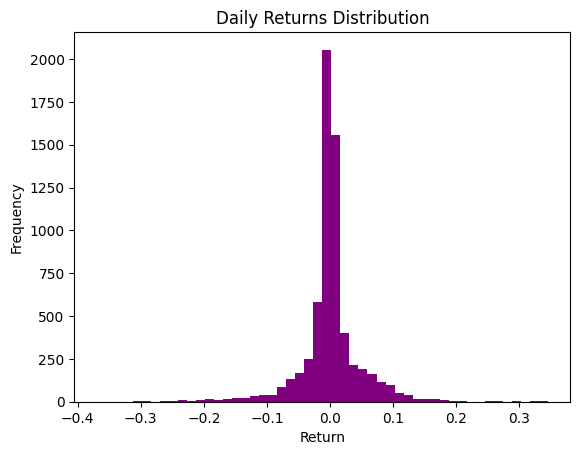

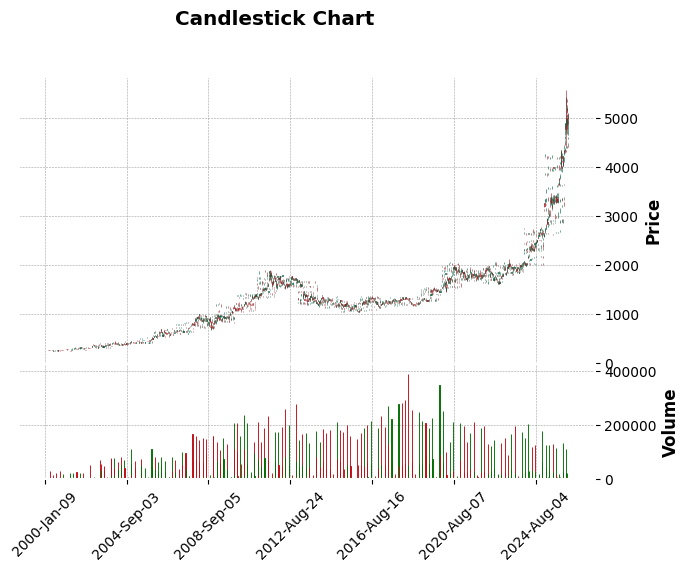

In [15]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date (important for time series)
df = df.sort_values('Date')

# Set Date as index
df.set_index('Date', inplace=True)

# -----------------------------
# 1. Line Plot (Price Trends)
# -----------------------------
plt.figure()
plt.plot(df.index, df['Open'], label='Open', color='blue')
plt.plot(df.index, df['High'], label='High', color='green')
plt.plot(df.index, df['Low'], label='Low', color='red')
plt.plot(df.index, df['Close'], label='Close', color='purple')
plt.title("Stock Price Trends")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# 2. Volume Bar Chart
# -----------------------------
plt.figure()
plt.bar(df.index, df['Volume'], color='orange')
plt.title("Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 3. Moving Average Plot
# -----------------------------
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

plt.figure()
plt.plot(df.index, df['Close'], label='Close Price', color='black')
plt.plot(df.index, df['MA20'], label='MA 20', color='blue')
plt.plot(df.index, df['MA50'], label='MA 50', color='red')
plt.title("Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# 4. High-Low Spread
# -----------------------------
plt.figure()
plt.fill_between(df.index, df['Low'], df['High'], color='lightgreen')
plt.title("High-Low Price Range")
plt.xlabel("Date")
plt.ylabel("Price Range")
plt.show()

# -----------------------------
# 5. Daily Returns Histogram
# -----------------------------
df['Daily Return'] = df['Close'].pct_change()

plt.figure()
plt.hist(df['Daily Return'].dropna(), bins=50, color='purple')
plt.title("Daily Returns Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# 6. Candlestick Chart (Optional)
# -----------------------------
# Install mplfinance first:
# pip install mplfinance

import mplfinance as mpf

mpf.plot(df, type='candle', style='charles', volume=True,
         title='Candlestick Chart',
         ylabel='Price',
         ylabel_lower='Volume')

## Feature engineering

In [16]:
print(df.columns)

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'MA20', 'MA50',
       'Daily Return'],
      dtype='object')


Logistic Regression Accuracy: 0.5551


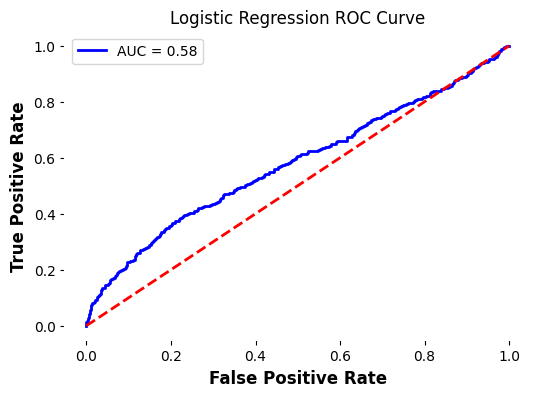

Random Forest Accuracy: 0.4827


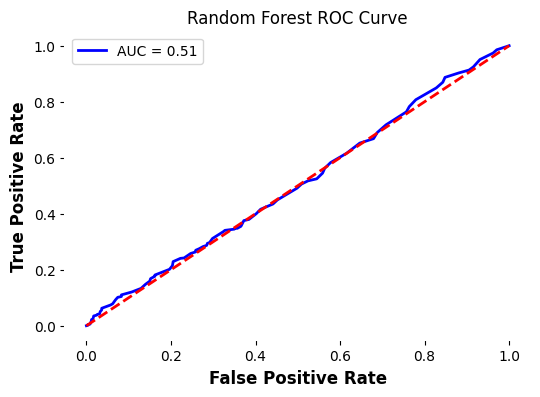

SVM Accuracy: 0.5441


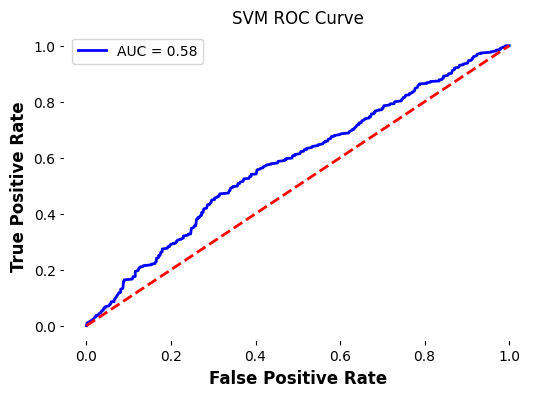

In [17]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Clean column names
df.columns = df.columns.str.strip()

# -----------------------------
# 2. Create Target (NO LEAKAGE)
# Predict next day's movement
# -----------------------------
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# Drop last row (no future value)
df = df.dropna()

# -----------------------------
# 3. Features & Target
# -----------------------------
features = ['Open', 'High', 'Low', 'Close', 'Volume',
            'MA20', 'MA50', 'Daily Return']

X = df[features]
y = df['Target']

# -----------------------------
# 4. Label Encoding
# -----------------------------
le = LabelEncoder()
y = le.fit_transform(y)

# -----------------------------
# 5. Train-Test Split (Time-based)
# NO shuffle → prevents leakage
# -----------------------------
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# -----------------------------
# 6. Scaling (ONLY train)
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# 7. Models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "SVM": SVC(probability=True)
}

# -----------------------------
# 8. Train + Evaluate
# -----------------------------
for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='blue')
    plt.plot([0,1], [0,1], linestyle='--', color='red')
    plt.title(f"{name} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()

## Thank you..pls upvote!!!!!!!
